In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

import sys
sys.path.insert(0,'../code')
import utils

%load_ext autoreload
%autoreload 2

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

matplotlib.rc('text', usetex=False)

In [3]:
tag_quaia = '_zmin0.0zmax1.0'
G_max = 20.5
tab_quaia = Table.read(f'../data/quaia_G{G_max}{tag_quaia}.fits')
#tab_quaia = Table.read('../data/quaia_G20.5_zsplit2bin0.fits')
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 324336


In [4]:
tab_rand = Table.read(f'../data/randoms/random_G{G_max}{tag_quaia}_10x.fits')
print("Columns:", tab_rand.columns)
print("N =", len(tab_rand))

Columns: <TableColumns names=('ra','dec','ebv')>
N = 3242045


In [5]:
ra, dec = tab_quaia['ra'], tab_quaia['dec']
ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
theta_edges = np.linspace(0.25, 10, 40)

In [6]:
import correlations
wtheta, DD_theta, DR_theta, RR_theta = correlations.compute_wtheta(theta_edges, ra, dec, ra_rand, dec_rand,
                   return_full_results=True, nthreads=16)

[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 3.4492 s
DR theta time: 86.5821 s
RR theta time: 421.8434 s
Total theta time: 511.8769 s


In [7]:
theta = (theta_edges[1:] + theta_edges[:-1]) / 2


Text(0, 0.5, '$w(\\theta)$')

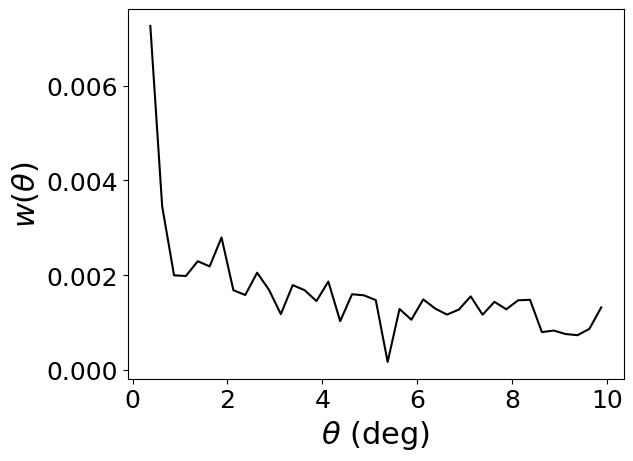

In [8]:
plt.plot(theta, wtheta, color='black')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$w(\theta)$')
#plt.yscale('log')